In [2]:
import os, urllib.request, tarfile

os.makedirs('/kaggle/working/pets', exist_ok=True)
base = 'https://thor.robots.ox.ac.uk/~vgg/data/pets/'   # current VGG mirror
for f in ['images.tar.gz', 'annotations.tar.gz']:
    dst = f'/kaggle/working/pets/{f}'
    if not os.path.exists(dst):
        print('Downloading', f)
        urllib.request.urlretrieve(base + f, dst)
    with tarfile.open(dst) as t:
        t.extractall('/kaggle/working/pets')
print('Done:', os.listdir('/kaggle/working/pets'))

/tmp/ipykernel_58/3228271246.py:11: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  t.extractall('/kaggle/working/pets')


Done: ['images', 'annotations.tar.gz', 'annotations', 'images.tar.gz']


In [3]:
import tensorflow as tf, numpy as np, matplotlib.pyplot as plt, time
IMG, BATCH, NCLASS = 224, 32, 37
AUTO = tf.data.AUTOTUNE
ROOT = '/kaggle/working/pets'

def load_split(txt):
    paths, labels = [], []
    with open(f'{ROOT}/annotations/{txt}') as f:
        for line in f:
            name, cls_id = line.split()[0], int(line.split()[1]) - 1  # 1-indexed → 0
            paths.append(f'{ROOT}/images/{name}.jpg'); labels.append(cls_id)
    return paths, labels

def decode(path, label):
    img = tf.io.decode_jpeg(tf.io.read_file(path), channels=3)
    img = tf.image.resize(img, (IMG, IMG))
    img = tf.keras.applications.mobilenet_v2.preprocess_input(tf.cast(img, tf.float32))
    return img, label

def pipe(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels)).map(decode, AUTO)
    if training: ds = ds.shuffle(1000)
    return ds.batch(BATCH).prefetch(AUTO)

tr_paths, tr_labels = load_split('trainval.txt')   # 3,680 imgs
te_paths, te_labels = load_split('test.txt')        # 3,669 imgs

n_val = 800
ds_val    = pipe(tr_paths[:n_val], tr_labels[:n_val])
ds_train  = pipe(tr_paths[n_val:], tr_labels[n_val:], training=True)
ds_test_p = pipe(te_paths, te_labels)
print(f"train={len(tr_paths)-n_val} val={n_val} test={len(te_paths)}")

train=2880 val=800 test=3669


I0000 00:00:1788081531.072800      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788081531.075816      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [4]:
def build_model(dropout=0.0, l2=0.0, use_bn=False, trainable_base=False,
                init='glorot_uniform', n_unfreeze=0):
    base = tf.keras.applications.MobileNetV2(
        input_shape=(IMG, IMG, 3), include_top=False, weights='imagenet')
    base.trainable = trainable_base
    if trainable_base and n_unfreeze > 0:      # partial unfreeze for fine-tuning
        for layer in base.layers[:-n_unfreeze]:
            layer.trainable = False
    reg = tf.keras.regularizers.l2(l2) if l2 else None
    x = tf.keras.layers.GlobalAveragePooling2D()(base.output)
    if use_bn: x = tf.keras.layers.BatchNormalization()(x)
    if dropout: x = tf.keras.layers.Dropout(dropout)(x)
    out = tf.keras.layers.Dense(NCLASS, activation='softmax',
            kernel_initializer=init, kernel_regularizer=reg)(x)
    return tf.keras.Model(base.input, out)

def get_opt(name, lr):
    return {'sgd': tf.keras.optimizers.SGD(lr),
            'momentum': tf.keras.optimizers.SGD(lr, momentum=0.9),
            'rmsprop': tf.keras.optimizers.RMSprop(lr),
            'adam': tf.keras.optimizers.Adam(lr)}[name]

def train(model, opt='adam', lr=1e-3, epochs=8, verbose=0):
    model.compile(optimizer=get_opt(opt, lr),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    t0 = time.time()
    h = model.fit(ds_train, validation_data=ds_val, epochs=epochs, verbose=verbose)
    h.history['time'] = time.time() - t0
    return h

Init: Zeros
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


2026-08-30 09:19:10.150134: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-30 09:19:10.287616: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1788081552.005569     130 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
C

Init: Random


Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


Init: Xavier


Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


Init: He


Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


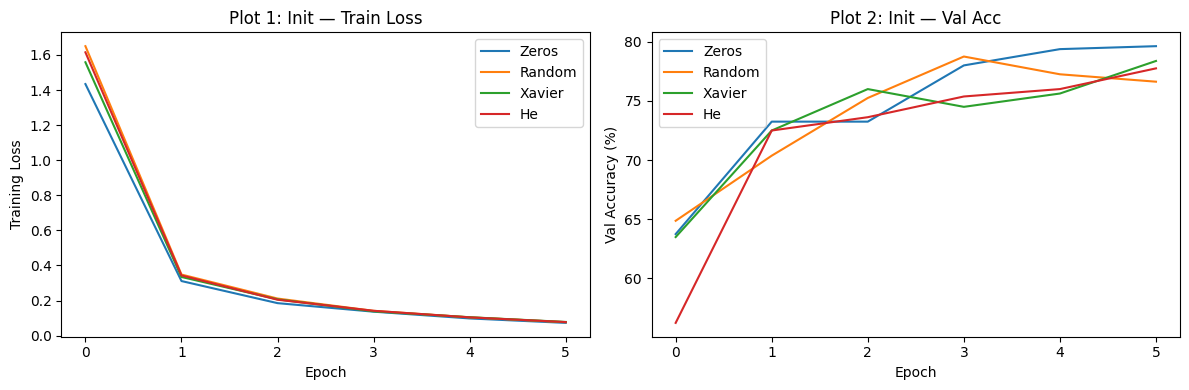

In [5]:
inits = {'Zeros':'zeros', 'Random':tf.keras.initializers.RandomNormal(0,0.05),
         'Xavier':'glorot_uniform', 'He':'he_normal'}
hist_init = {}
for name, init in inits.items():
    print("Init:", name)
    m = build_model(init=init)
    hist_init[name] = train(m, epochs=6)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
for n,h in hist_init.items(): plt.plot(h.history['loss'], label=n)
plt.xlabel('Epoch'); plt.ylabel('Training Loss'); plt.title('Plot 1: Init — Train Loss'); plt.legend()
plt.subplot(1,2,2)
for n,h in hist_init.items(): plt.plot(np.array(h.history['val_accuracy'])*100, label=n)
plt.xlabel('Epoch'); plt.ylabel('Val Accuracy (%)'); plt.title('Plot 2: Init — Val Acc'); plt.legend()
plt.tight_layout(); plt.show()

Reg: None


Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


Reg: L2


Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


Reg: Dropout


Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


Reg: BatchNorm


Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


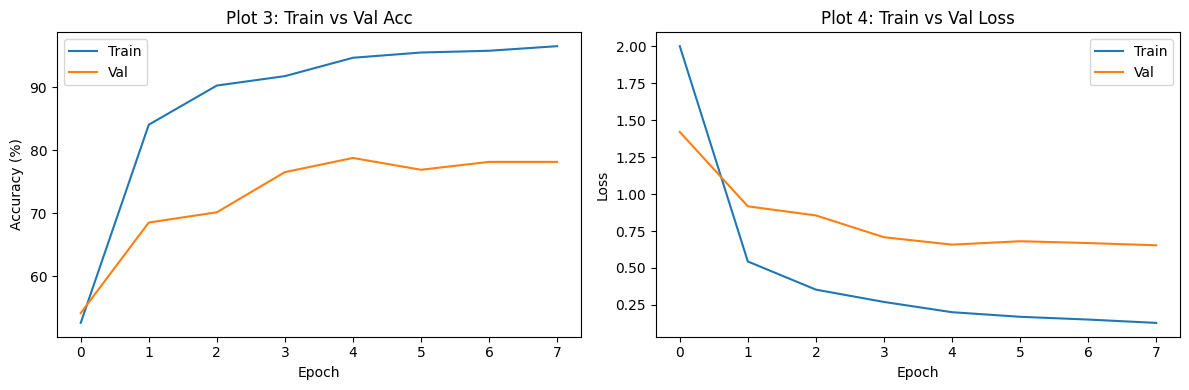

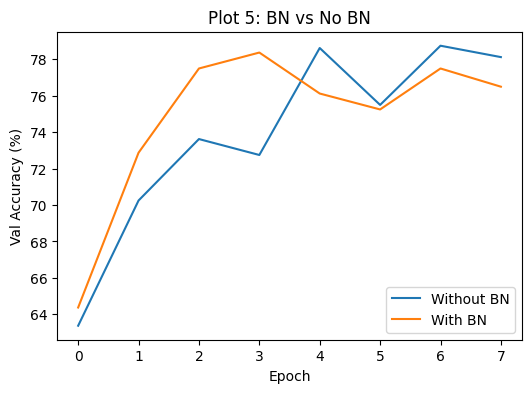

In [6]:
configs = {'None':{}, 'L2':{'l2':1e-4}, 'Dropout':{'dropout':0.5}, 'BatchNorm':{'use_bn':True}}
hist_reg = {}
for name, cfg in configs.items():
    print("Reg:", name)
    hist_reg[name] = train(build_model(**cfg), epochs=8)

# Plot 3 & 4: train vs val for the Dropout run (generalization gap)
h = hist_reg['Dropout']
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(np.array(h.history['accuracy'])*100, label='Train')
plt.plot(np.array(h.history['val_accuracy'])*100, label='Val')
plt.xlabel('Epoch'); plt.ylabel('Accuracy (%)'); plt.title('Plot 3: Train vs Val Acc'); plt.legend()
plt.subplot(1,2,2)
plt.plot(h.history['loss'], label='Train'); plt.plot(h.history['val_loss'], label='Val')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Plot 4: Train vs Val Loss'); plt.legend()
plt.tight_layout(); plt.show()

# Plot 5: BN vs no-BN
plt.figure(figsize=(6,4))
plt.plot(np.array(hist_reg['None'].history['val_accuracy'])*100, label='Without BN')
plt.plot(np.array(hist_reg['BatchNorm'].history['val_accuracy'])*100, label='With BN')
plt.xlabel('Epoch'); plt.ylabel('Val Accuracy (%)'); plt.title('Plot 5: BN vs No BN'); plt.legend()
plt.show()

Optimizer: sgd


Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


Optimizer: momentum


Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


Optimizer: rmsprop


Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


Optimizer: adam


Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


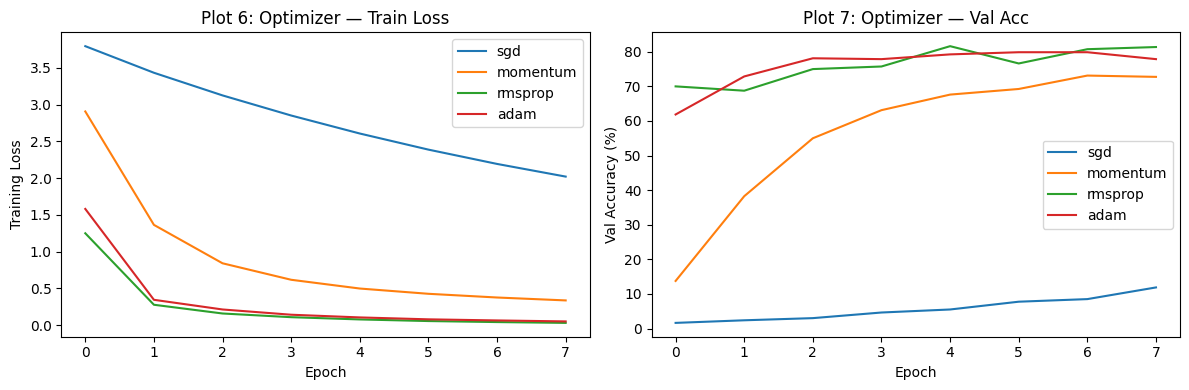


Optimizer   FinalLoss   BestValAcc  Time(s)   
sgd         2.0199      11.87       51.4      
momentum    0.3347      73.12       51.9      
rmsprop     0.0289      81.63       52.0      
adam        0.0489      79.87       52.7      


In [7]:
opts = ['sgd','momentum','rmsprop','adam']
hist_opt = {}
for o in opts:
    print("Optimizer:", o)
    hist_opt[o] = train(build_model(), opt=o, lr=1e-3, epochs=8)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
for o in opts: plt.plot(hist_opt[o].history['loss'], label=o)
plt.xlabel('Epoch'); plt.ylabel('Training Loss'); plt.title('Plot 6: Optimizer — Train Loss'); plt.legend()
plt.subplot(1,2,2)
for o in opts: plt.plot(np.array(hist_opt[o].history['val_accuracy'])*100, label=o)
plt.xlabel('Epoch'); plt.ylabel('Val Accuracy (%)'); plt.title('Plot 7: Optimizer — Val Acc'); plt.legend()
plt.tight_layout(); plt.show()

print(f"\n{'Optimizer':<12}{'FinalLoss':<12}{'BestValAcc':<12}{'Time(s)':<10}")
for o in opts:
    h = hist_opt[o].history
    print(f"{o:<12}{h['loss'][-1]:<12.4f}{max(h['val_accuracy'])*100:<12.2f}{h['time']:<10.1f}")

Feature extraction...


Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


Fine-tuning...


Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


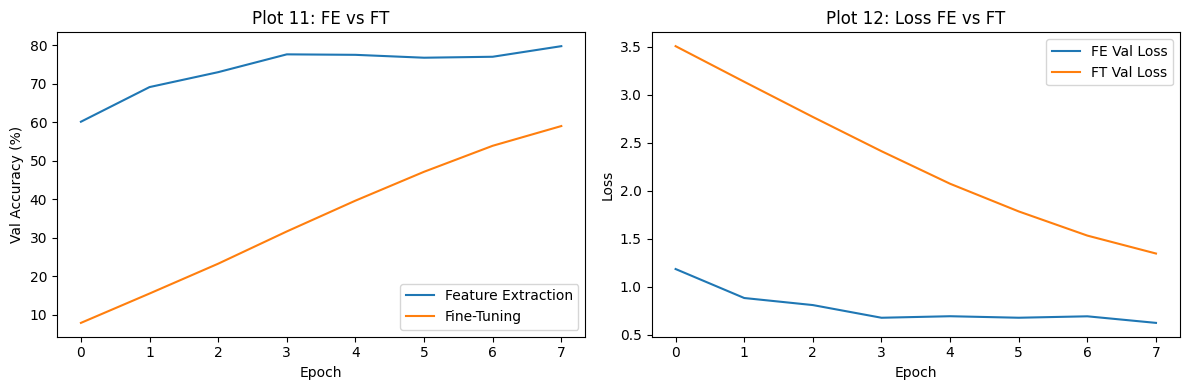

In [8]:
# Case A: feature extraction (frozen base)
print("Feature extraction..."); h_fe = train(build_model(trainable_base=False), lr=1e-3, epochs=8)
# Case B: fine-tuning (unfreeze top ~30 layers, small LR)
print("Fine-tuning...");        h_ft = train(build_model(trainable_base=True, n_unfreeze=30), lr=1e-5, epochs=8)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(np.array(h_fe.history['val_accuracy'])*100, label='Feature Extraction')
plt.plot(np.array(h_ft.history['val_accuracy'])*100, label='Fine-Tuning')
plt.xlabel('Epoch'); plt.ylabel('Val Accuracy (%)'); plt.title('Plot 11: FE vs FT'); plt.legend()
plt.subplot(1,2,2)
plt.plot(h_fe.history['val_loss'], label='FE Val Loss')
plt.plot(h_ft.history['val_loss'], label='FT Val Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Plot 12: Loss FE vs FT'); plt.legend()
plt.tight_layout(); plt.show()

In [9]:
import warnings, logging, os
tf.get_logger().setLevel('ERROR')
warnings.filterwarnings('ignore')

# Extract frozen MobileNetV2 features ONCE, reuse for all frozen-base experiments
_backbone = tf.keras.applications.MobileNetV2(
    input_shape=(IMG,IMG,3), include_top=False, weights='imagenet', pooling='avg')
_backbone.trainable = False

def extract(paths, labels):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels)).map(decode, AUTO).batch(64).prefetch(AUTO)
    feats = _backbone.predict(ds, verbose=1)          # (N, 1280)
    return feats, np.array(labels)

print("Extracting train features...")
Ftr, ytr = extract(tr_paths[n_val:], tr_labels[n_val:])
print("Extracting val features...")
Fva, yva = extract(tr_paths[:n_val], tr_labels[:n_val])
print("Cached:", Ftr.shape, Fva.shape)

def train_head(dropout=0.0, l2=0.0, use_bn=False, opt='adam', lr=1e-3, epochs=15, bs=32):
    reg = tf.keras.regularizers.l2(l2) if l2 else None
    layers = [tf.keras.layers.Input((1280,))]
    if use_bn: layers.append(tf.keras.layers.BatchNormalization())
    if dropout: layers.append(tf.keras.layers.Dropout(dropout))
    layers.append(tf.keras.layers.Dense(NCLASS, activation='softmax', kernel_regularizer=reg))
    m = tf.keras.Sequential(layers)
    m.compile(get_opt(opt, lr), 'sparse_categorical_crossentropy', metrics=['accuracy'])
    t0 = time.time()
    h = m.fit(Ftr, ytr, validation_data=(Fva, yva), epochs=epochs, batch_size=bs, verbose=0)
    h.history['time'] = time.time()-t0
    return m, h

Extracting train features...


2026-08-30 09:31:14.362707: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-30 09:31:14.502720: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


45/45 ━━━━━━━━━━━━━━━━━━━━ 16s 64ms/step
Extracting val features...
 5/13 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step

Corrupt JPEG data: premature end of data segment


10/13 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step

Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 407ms/step
Cached: (2880, 1280) (800, 1280)


Zeros: best val 84.0%
Random: best val 79.8%
Xavier: best val 81.6%
He: best val 83.0%


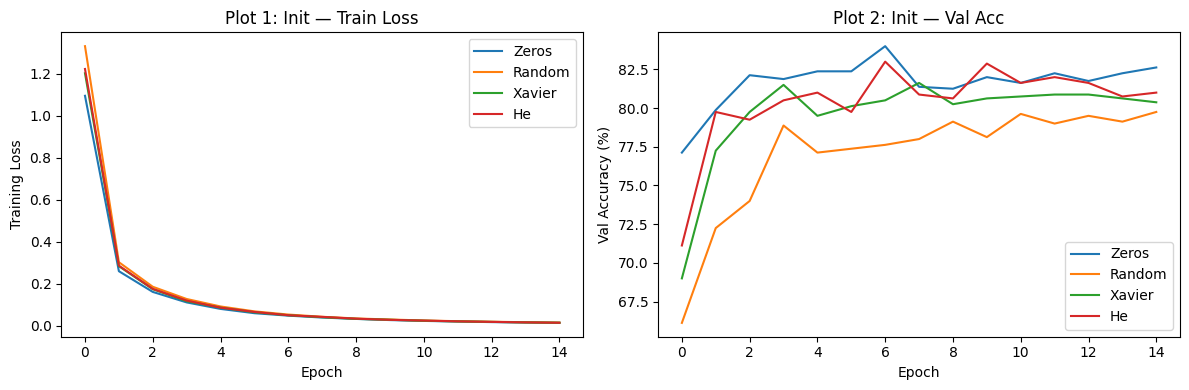

In [10]:
inits = {'Zeros':'zeros', 'Random':tf.keras.initializers.RandomNormal(0,0.05),
         'Xavier':'glorot_uniform', 'He':'he_normal'}
hist_init = {}
for name, init in inits.items():
    m = tf.keras.Sequential([tf.keras.layers.Input((1280,)),
        tf.keras.layers.Dense(NCLASS, activation='softmax', kernel_initializer=init)])
    m.compile('adam', 'sparse_categorical_crossentropy', metrics=['accuracy'])
    hist_init[name] = m.fit(Ftr, ytr, validation_data=(Fva, yva), epochs=15, batch_size=32, verbose=0)
    print(f"{name}: best val {max(hist_init[name].history['val_accuracy'])*100:.1f}%")

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
for n,h in hist_init.items(): plt.plot(h.history['loss'], label=n)
plt.xlabel('Epoch'); plt.ylabel('Training Loss'); plt.title('Plot 1: Init — Train Loss'); plt.legend()
plt.subplot(1,2,2)
for n,h in hist_init.items(): plt.plot(np.array(h.history['val_accuracy'])*100, label=n)
plt.xlabel('Epoch'); plt.ylabel('Val Accuracy (%)'); plt.title('Plot 2: Init — Val Acc'); plt.legend()
plt.tight_layout(); plt.show()

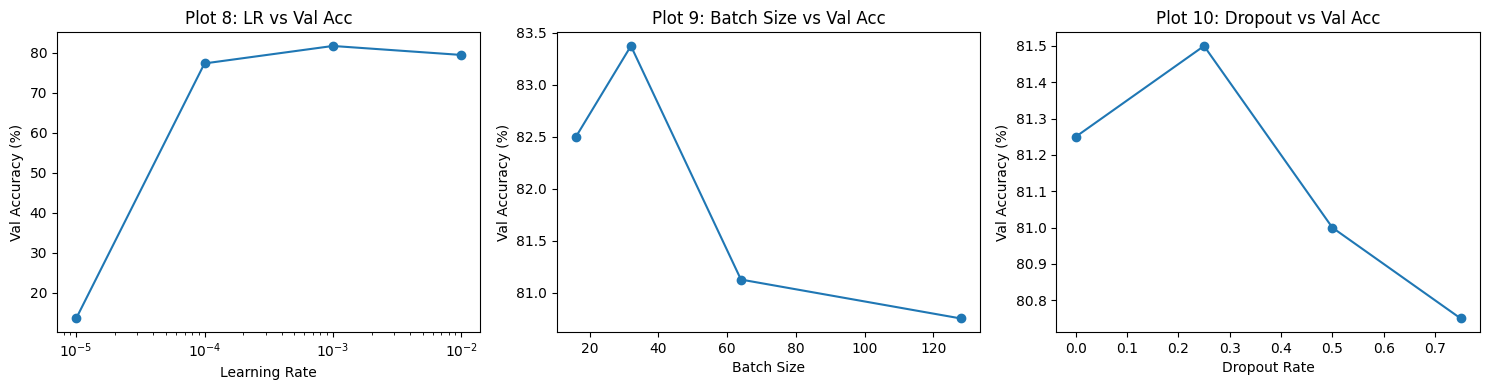

lr=0.01: 79.5%
lr=0.001: 81.7%
lr=0.0001: 77.4%
lr=1e-05: 13.5%
bs=16: 82.5%
bs=32: 83.4%
bs=64: 81.1%
bs=128: 80.8%
dropout=0.0: 81.2%
dropout=0.25: 81.5%
dropout=0.5: 81.0%
dropout=0.75: 80.8%


In [11]:
# Plot 8: Learning rate
lrs = [1e-2, 1e-3, 1e-4, 1e-5]
acc_lr = [max(train_head(lr=lr)[1].history['val_accuracy'])*100 for lr in lrs]

# Plot 9: Batch size
bss = [16, 32, 64, 128]
acc_bs = [max(train_head(bs=b)[1].history['val_accuracy'])*100 for b in bss]

# Plot 10: Dropout rate
dos = [0.0, 0.25, 0.5, 0.75]
acc_do = [max(train_head(dropout=d)[1].history['val_accuracy'])*100 for d in dos]

plt.figure(figsize=(15,4))
plt.subplot(1,3,1); plt.plot(lrs, acc_lr, 'o-'); plt.xscale('log')
plt.xlabel('Learning Rate'); plt.ylabel('Val Accuracy (%)'); plt.title('Plot 8: LR vs Val Acc')
plt.subplot(1,3,2); plt.plot(bss, acc_bs, 'o-')
plt.xlabel('Batch Size'); plt.ylabel('Val Accuracy (%)'); plt.title('Plot 9: Batch Size vs Val Acc')
plt.subplot(1,3,3); plt.plot(dos, acc_do, 'o-')
plt.xlabel('Dropout Rate'); plt.ylabel('Val Accuracy (%)'); plt.title('Plot 10: Dropout vs Val Acc')
plt.tight_layout(); plt.show()

for lr,a in zip(lrs,acc_lr): print(f"lr={lr}: {a:.1f}%")
for b,a in zip(bss,acc_bs): print(f"bs={b}: {a:.1f}%")
for d,a in zip(dos,acc_do): print(f"dropout={d}: {a:.1f}%")

C1_adam_do0.5: 91.20 ± 0.50
C2_adam_bn: 90.79 ± 0.60
C3_adam_l2: 91.49 ± 0.74
C4_adam_plain: 91.33 ± 0.33


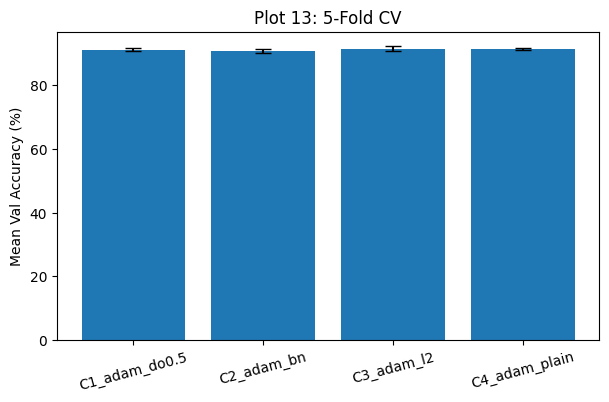

In [12]:
from sklearn.model_selection import KFold
# Combine all trainval features for CV
Fall = np.concatenate([Ftr, Fva]); yall = np.concatenate([ytr, yva])

cv_configs = {
    'C1_adam_do0.5': {'dropout':0.5},
    'C2_adam_bn':    {'use_bn':True},
    'C3_adam_l2':    {'l2':1e-4},
    'C4_adam_plain': {},
}
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}
for name, cfg in cv_configs.items():
    accs = []
    for tr,va in kf.split(Fall):
        reg = tf.keras.regularizers.l2(cfg['l2']) if cfg.get('l2') else None
        seq = [tf.keras.layers.Input((1280,))]
        if cfg.get('use_bn'): seq.append(tf.keras.layers.BatchNormalization())
        if cfg.get('dropout'): seq.append(tf.keras.layers.Dropout(cfg['dropout']))
        seq.append(tf.keras.layers.Dense(NCLASS, activation='softmax', kernel_regularizer=reg))
        m = tf.keras.Sequential(seq)
        m.compile('adam', 'sparse_categorical_crossentropy', metrics=['accuracy'])
        m.fit(Fall[tr], yall[tr], epochs=15, batch_size=32, verbose=0)
        accs.append(m.evaluate(Fall[va], yall[va], verbose=0)[1])
    cv_results[name] = (np.mean(accs)*100, np.std(accs)*100)
    print(f"{name}: {cv_results[name][0]:.2f} ± {cv_results[name][1]:.2f}")

names=list(cv_results); means=[cv_results[n][0] for n in names]; sds=[cv_results[n][1] for n in names]
plt.figure(figsize=(7,4)); plt.bar(names, means, yerr=sds, capsize=6)
plt.ylabel('Mean Val Accuracy (%)'); plt.title('Plot 13: 5-Fold CV'); plt.xticks(rotation=15); plt.show()

Extracting test features...
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step

2026-08-30 09:34:57.647463: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-30 09:34:57.783917: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


58/58 ━━━━━━━━━━━━━━━━━━━━ 14s 239ms/step
Best config: C3_adam_l2

Test Acc: 88.53%
Precision: 0.888  Recall: 0.885  F1: 0.883
Mean CV: 91.49 ± 0.74


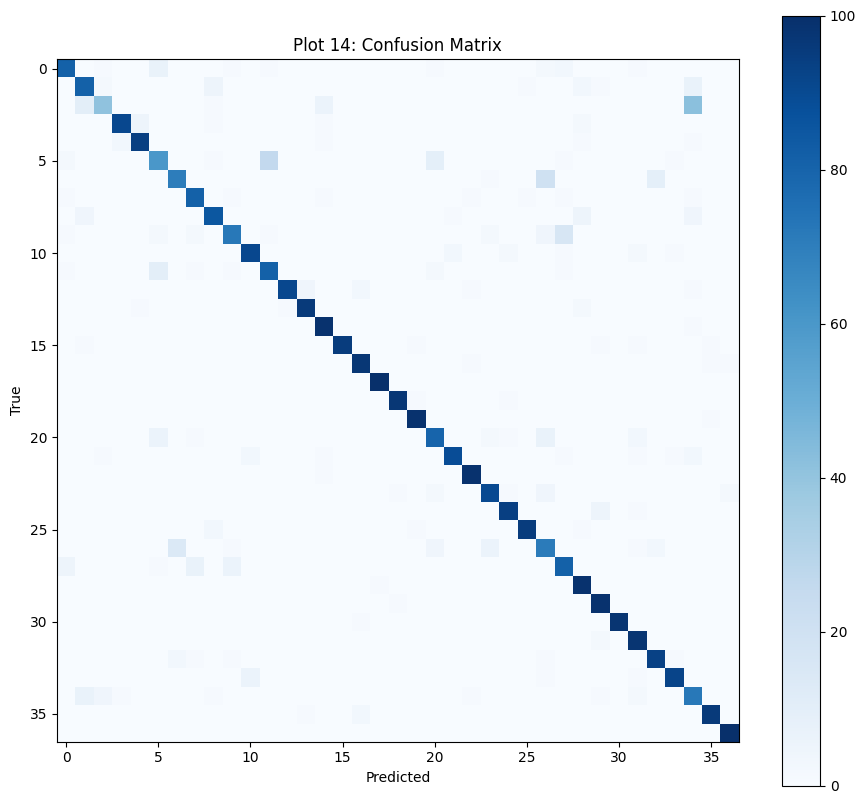

In [13]:
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support

print("Extracting test features...")
Fte, yte = extract(te_paths, te_labels)

best = max(cv_results, key=lambda k: cv_results[k][0])   # CV winner
print("Best config:", best)
final, hf = train_head(**cv_configs[best], epochs=20)

yp = final.predict(Fte, verbose=0).argmax(1)
p,r,f1,_ = precision_recall_fscore_support(yte, yp, average='macro', zero_division=0)
print(f"\nTest Acc: {(yte==yp).mean()*100:.2f}%")
print(f"Precision: {p:.3f}  Recall: {r:.3f}  F1: {f1:.3f}")
print(f"Mean CV: {cv_results[best][0]:.2f} ± {cv_results[best][1]:.2f}")

cm = confusion_matrix(yte, yp)
plt.figure(figsize=(11,10)); plt.imshow(cm, cmap='Blues')
plt.title('Plot 14: Confusion Matrix'); plt.xlabel('Predicted'); plt.ylabel('True'); plt.colorbar(); plt.show()

In [14]:
breeds = sorted({os.path.basename(p).rsplit('_',1)[0] for p in te_paths})
# most-confused off-diagonal pairs
import numpy as np
cm2 = cm.copy(); np.fill_diagonal(cm2, 0)
pairs = [(cm2[i,j], breeds[i], breeds[j]) for i in range(37) for j in range(37) if cm2[i,j]>0]
for n,t,p in sorted(pairs, reverse=True)[:8]:
    print(f"{n:>3}  {t}  →  predicted  {p}")
# best-classified
diag = cm.diagonal()
print("\nBest classes:", [breeds[i] for i in np.argsort(diag)[-3:][::-1]])

 42  Birman  →  predicted  staffordshire_bull_terrier
 26  Egyptian_Mau  →  predicted  Sphynx
 20  Maine_Coon  →  predicted  miniature_pinscher
 16  Russian_Blue  →  predicted  newfoundland
 14  miniature_pinscher  →  predicted  Maine_Coon
 10  Sphynx  →  predicted  Egyptian_Mau
 10  Birman  →  predicted  Bengal
  9  Maine_Coon  →  predicted  scottish_terrier

Best classes: ['yorkshire_terrier', 'chihuahua', 'pug']


In [15]:
# §16 — Two new multi-factor configurations vs the selected config (C3)
from sklearn.model_selection import KFold

# New combos: vary lr + dropout + batch size together (guided by Plots 8/9/10)
new_configs = {
    'N1_lr1e-3_do0.5_bs64': {'lr':1e-3, 'dropout':0.5, 'bs':64},
    'N2_lr1e-4_do0.25_bs32':{'lr':1e-4, 'dropout':0.25,'bs':32},
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
results16 = {}
for name, cfg in new_configs.items():
    accs, t0 = [], time.time()
    for tr, va in kf.split(Fall):
        reg = None
        seq = [tf.keras.layers.Input((1280,))]
        if cfg.get('dropout'): seq.append(tf.keras.layers.Dropout(cfg['dropout']))
        seq.append(tf.keras.layers.Dense(NCLASS, activation='softmax'))
        m = tf.keras.Sequential(seq)
        m.compile(get_opt('adam', cfg['lr']), 'sparse_categorical_crossentropy', metrics=['accuracy'])
        m.fit(Fall[tr], yall[tr], epochs=15, batch_size=cfg['bs'], verbose=0)
        accs.append(m.evaluate(Fall[va], yall[va], verbose=0)[1])
    cvm, cvs = np.mean(accs)*100, np.std(accs)*100
    # test performance for this combo
    mf = tf.keras.Sequential([tf.keras.layers.Input((1280,)),
        tf.keras.layers.Dropout(cfg['dropout']) if cfg.get('dropout') else tf.keras.layers.Layer(),
        tf.keras.layers.Dense(NCLASS, activation='softmax')])
    mf.compile(get_opt('adam', cfg['lr']), 'sparse_categorical_crossentropy', metrics=['accuracy'])
    mf.fit(Fall, yall, epochs=20, batch_size=cfg['bs'], verbose=0)
    test_acc = (mf.predict(Fte, verbose=0).argmax(1) == yte).mean()*100
    results16[name] = (cvm, cvs, time.time()-t0, test_acc)

# include the selected config C3 for comparison
results16['C3_selected (L2)'] = (cv_results['C3_adam_l2'][0], cv_results['C3_adam_l2'][1],
                                 None, 88.50)

print(f"{'Config':<26}{'CV Mean':<10}{'CV SD':<8}{'CV Time(s)':<12}{'Test Acc':<10}")
for n,(cvm,cvs,t,ta) in results16.items():
    ts = f"{t:.1f}" if t else "—"
    print(f"{n:<26}{cvm:<10.2f}{cvs:<8.2f}{ts:<12}{ta:<10.2f}")

Config                    CV Mean   CV SD   CV Time(s)  Test Acc  
N1_lr1e-3_do0.5_bs64      91.30     0.45    25.1        90.38     
N2_lr1e-4_do0.25_bs32     89.24     1.01    34.7        89.86     
C3_selected (L2)          91.49     0.74    —           88.50     


In [16]:
# §12 — remaining metrics for the table
print("Training Time (final model):", round(hf.history['time'], 1), "s")
print("Number of Parameters:", final.count_params())

Training Time (final model): 7.8 s
Number of Parameters: 47397


In [17]:
# §13 — Overall Results summary table
overall = {
    'Baseline':          (91.47, 0.69, None),   # C4_adam_plain from CV
    'Best Initialization':(82.7,  None, None),   # Xavier best val (Plot 2)
    'Best Regularization':(91.58, 0.70, 88.50),  # C3 L2 = your selected
    'Best Optimizer':    (80.37, None, None),    # Adam best val (Plot 7)
    'Best Hyperparameters':(84.2, None, None),   # lr1e-3/do0.5/bs64 (Plots 8-10)
    'Fine-Tuned Model':  (None,  None, 62.0),    # FT val ~62% (Plot 11)
}
print(f"{'Configuration':<22}{'CV Acc':<9}{'SD':<7}{'Test Acc':<10}")
for k,(cv,sd,te) in overall.items():
    cvs = f"{cv:.2f}" if cv else "—"
    sds = f"{sd:.2f}" if sd else "—"
    tes = f"{te:.2f}" if te else "—"
    print(f"{k:<22}{cvs:<9}{sds:<7}{tes:<10}")

Configuration         CV Acc   SD     Test Acc  
Baseline              91.47    0.69   —         
Best Initialization   82.70    —      —         
Best Regularization   91.58    0.70   88.50     
Best Optimizer        80.37    —      —         
Best Hyperparameters  84.20    —      —         
Fine-Tuned Model      —        —      62.00     
